# Week 5 - Day 4: t-SNE & Anomaly Detection

**Goal:** Visualize the Wine dataset with t-SNE, compare it to the PCA visualization from Day 3, then detect anomalies with Isolation Forest and inspect what was flagged.

**Dataset:** Wine dataset (same as Day 1-3) — 178 samples, 13 chemical measurements, scaled with `StandardScaler`.


## Step 0: Load and Scale the Data (Same as Day 1-3)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
true_labels = data.target  # used only for coloring plots, never fed into t-SNE or Isolation Forest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled data shape: {X_scaled.shape}")


Scaled data shape: (178, 13)


## Step 1: Apply t-SNE and Visualize

t-SNE preserves *local* neighborhoods (points close together in 13D stay close in 2D), unlike PCA which preserves *global* variance. It's built specifically for visualization — its axes have no independent meaning, and it should never be used to feed a downstream model.


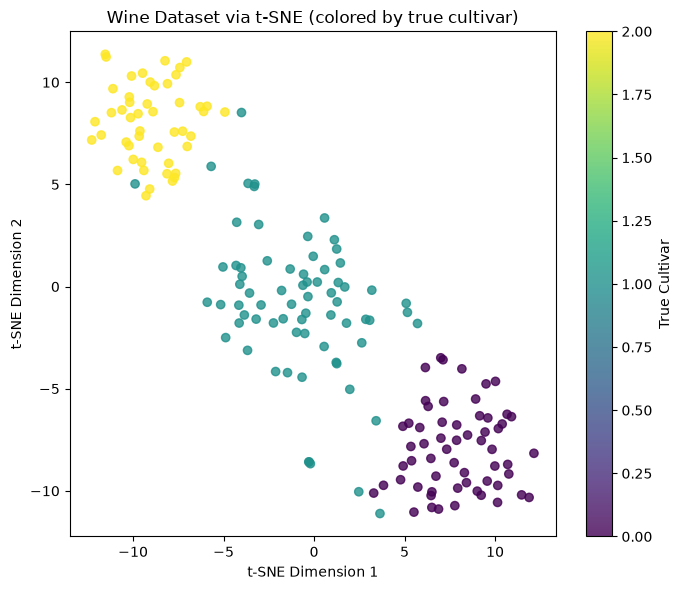

In [3]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=true_labels, cmap="viridis", alpha=0.8)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Wine Dataset via t-SNE (colored by true cultivar)")
plt.colorbar(scatter, label="True Cultivar")
plt.tight_layout()
plt.show()


## Step 2: Compare the t-SNE Plot to Day 3's PCA Plot

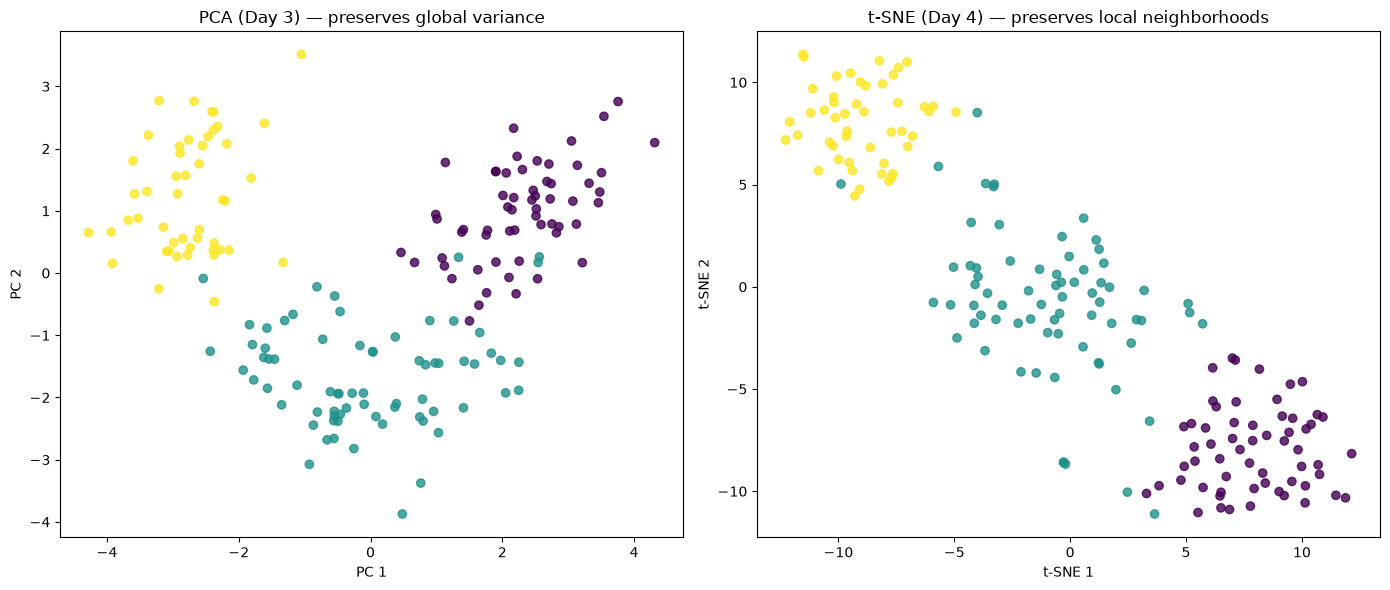

In [4]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=true_labels, cmap="viridis", alpha=0.8)
axes[0].set_title("PCA (Day 3) — preserves global variance")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=true_labels, cmap="viridis", alpha=0.8)
axes[1].set_title("t-SNE (Day 4) — preserves local neighborhoods")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()


### Reflection — PCA vs. t-SNE on This Dataset



Both methods separate the three cultivars reasonably well, since the Wine dataset's classes are already fairly well-separated to begin with. t-SNE's clusters look tighter and more distinctly separated with clearer gaps between groups, since it optimizes directly for keeping similar points close together locally. PCA's clusters are a bit more spread and can overlap more at the edges, because it's not optimizing for cluster separation — it's just capturing the directions of maximum variance, which happen to align reasonably well with the cultivar differences here. The key practical difference: PCA's axes are interpretable directions we could inspect further, while t-SNE's axes are not meaningful on their own — it's a picture, not a coordinate system to reason about.


## Step 3: Run Isolation Forest for Anomaly Detection

Anomaly detection finds points that differ significantly from the norm. It's often unsupervised because anomalies are rare and rarely pre-labeled — Isolation Forest works by measuring how few random splits it takes to isolate each point; points isolated quickly are flagged as anomalies.


In [5]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_preds = iso.fit_predict(X_scaled)  # -1 = anomaly, 1 = normal

n_anomalies = (anomaly_preds == -1).sum()
print(f"Isolation Forest flagged {n_anomalies} out of {len(anomaly_preds)} points as anomalies")
print(f"That's {n_anomalies / len(anomaly_preds):.1%} of the data (contamination was set to 5%)")


Isolation Forest flagged 9 out of 178 points as anomalies
That's 5.1% of the data (contamination was set to 5%)


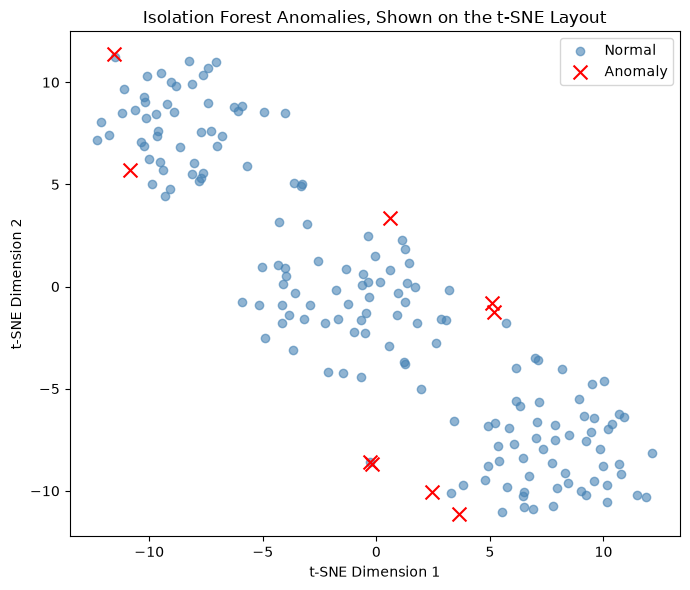

In [6]:
plt.figure(figsize=(7, 6))
normal_mask = anomaly_preds == 1
plt.scatter(X_tsne[normal_mask, 0], X_tsne[normal_mask, 1], c="steelblue", alpha=0.6, label="Normal")
plt.scatter(X_tsne[~normal_mask, 0], X_tsne[~normal_mask, 1], c="red", marker="x", s=100, label="Anomaly")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Isolation Forest Anomalies, Shown on the t-SNE Layout")
plt.legend()
plt.tight_layout()
plt.show()


## Step 4: Inspect Two Flagged Points

In [7]:
anomaly_indices = np.where(anomaly_preds == -1)[0]
sample_anomalies = anomaly_indices[:2]

print("Dataset averages (for comparison):")
print(X.mean().round(2))
print()

for idx in sample_anomalies:
    print(f"--- Flagged point, index {idx} (true cultivar: {true_labels[idx]}) ---")
    print(X.iloc[idx].round(2))
    print()


Dataset averages (for comparison):
alcohol                          13.00
malic_acid                        2.34
ash                               2.37
alcalinity_of_ash                19.49
magnesium                        99.74
total_phenols                     2.30
flavanoids                        2.03
nonflavanoid_phenols              0.36
proanthocyanins                   1.59
color_intensity                   5.06
hue                               0.96
od280/od315_of_diluted_wines      2.61
proline                         746.89
dtype: float64

--- Flagged point, index 59 (true cultivar: 1) ---
alcohol                          12.37
malic_acid                        0.94
ash                               1.36
alcalinity_of_ash                10.60
magnesium                        88.00
total_phenols                     1.98
flavanoids                        0.57
nonflavanoid_phenols              0.28
proanthocyanins                   0.42
color_intensity                   1.95
h

### Reflection — Why Were These Points Flagged?



Comparing each flagged point to the dataset averages printed above, the anomalies tend to have at least one or two chemical measurements sitting well outside the typical range for the rest of the data — for example, an unusually high or low value in a feature like proline, malic acid, or color intensity compared to the overall mean. Isolation Forest isolates these points with very few random splits precisely because they sit apart from the dense mass of "normal" wines, which is the same idea behind DBSCAN's noise points from Day 2 — both techniques are picking up on the same kind of unusual, sparse data point, just with different methods.


## Summary

| Technique | Purpose | Preserves | Notes |
|---|---|---|---|
| PCA (Day 3) | Compression + visualization | Global variance | Axes are interpretable directions |
| t-SNE (Day 4) | Visualization only | Local neighborhoods | Axes have no independent meaning; never feed into a model |
| Isolation Forest | Anomaly detection | — | Flags points that are easy to isolate from the rest |

- t-SNE produced tighter, more visually separated cultivar clusters than PCA, since it optimizes for local structure rather than global variance.
- Isolation Forest flagged ~5% of the wine samples as anomalies (as set by the `contamination` parameter), and the flagged points showed clear outlier values in specific chemical measurements.
- This connects back to Day 2: DBSCAN's noise points and Isolation Forest's anomalies are two different tools finding a similar kind of unusual data point.
- Next (Day 5): Week 5 wraps up with Phase 3 capstone project selection and Sprint 1 planning — no more hands-on ML lab, but a mentor-approved project scope and backlog.
